原始权重: 0.4, 原始得分: 78.0


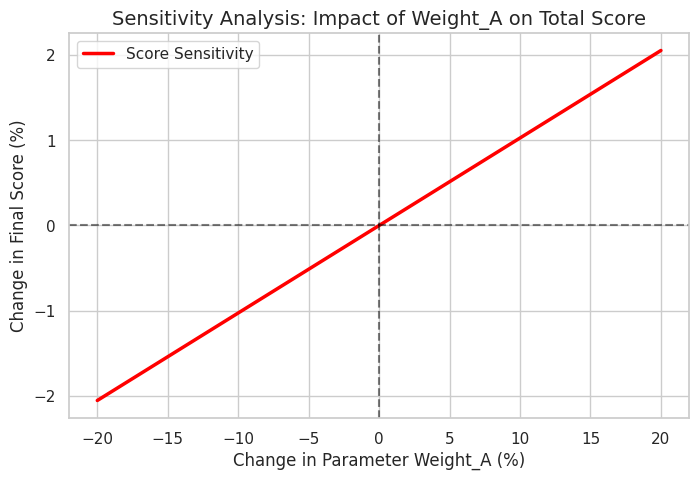

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 定义你的模型 (这里是你要修改的地方)
# ==========================================
def run_my_model(weight_A, value_A, value_B):
    """
    假设这是一个简单的评价模型：
    得分 = 权重A * 指标A + (1 - 权重A) * 指标B
    """
    weight_B = 1 - weight_A
    final_score = weight_A * value_A + weight_B * value_B
    return final_score

# ==========================================
# 2. 设置基准参数 (Base Case)
# ==========================================
# 假设我们在论文里定的权重是 0.4
base_weight_A = 0.4
# 假设数据是固定的
fixed_value_A = 90
fixed_value_B = 70

# 计算原始得分
base_score = run_my_model(base_weight_A, fixed_value_A, fixed_value_B)
print(f"原始权重: {base_weight_A}, 原始得分: {base_score}")

# ==========================================
# 3. 开始灵敏度分析 (让权重波动 ±20%)
# ==========================================
# 生成变动比例：从 -20% 到 +20%，切成 50 份
change_rates = np.linspace(-0.20, 0.20, 50) 

results = []
x_axis = [] # 记录变化的百分比

for rate in change_rates:
    # 让参数发生变动
    current_weight = base_weight_A * (1 + rate)
    
    # 重新跑模型
    new_score = run_my_model(current_weight, fixed_value_A, fixed_value_B)
    
    # 记录结果变化率 (新得分相对于旧得分变了多少)
    score_change_percent = (new_score - base_score) / base_score * 100
    
    results.append(score_change_percent)
    x_axis.append(rate * 100) # 把小数变成百分数用于画图

# ==========================================
# 4. 画图展示 (Sensitivity Plot)
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 画线
plt.plot(x_axis, results, color='red', linewidth=2.5, label='Score Sensitivity')

# 画基准线 (十字线)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # 水平线
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # 垂直线

# 装饰图片
plt.title("Sensitivity Analysis: Impact of Weight_A on Total Score", fontsize=14)
plt.xlabel("Change in Parameter Weight_A (%)", fontsize=12)
plt.ylabel("Change in Final Score (%)", fontsize=12)
plt.legend()

# 保存
plt.savefig("sensitivity_analysis.png", dpi=300)
plt.show()